## 1. Imports y configuración

In [1]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import percentileofscore
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "resilience_analysis")
os.makedirs(PLOTS_DIR, exist_ok=True)
MODEL_ORDER = ["AE", "VAE"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Imports completados")
print(f"Directorio de plots: {PLOTS_DIR}")

Imports completados
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis


## 2. Definición de arquitecturas AE y VAE

In [27]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, p_drop=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

print("Arquitecturas AE y VAE definidas")

Arquitecturas AE y VAE definidas


## 3. Carga de datos del Experimento 1

In [28]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print()

# Buscar el archivo más reciente automáticamente
import glob
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

# Ordenar por fecha de modificación (más reciente primero)
export_path = max(available_files, key=os.path.getmtime)

print(f"Archivo más reciente encontrado: {os.path.basename(export_path)}")
print(f"Ruta completa: {export_path}")
print()

if os.path.exists(export_path):
    print(f"Cargando datos...")
    print()
    
    with open(export_path, "rb") as f:
        exp1_data = pickle.load(f)
    
    # 1. Cargar modelos PyTorch
    print("1. Cargando modelos PyTorch...")
    models_path = exp1_data["models_path"]
    model_dims = exp1_data["model_dims"]
    
    MODELS = {}
    for model_key, model_file in models_path.items():
        dims = model_dims[model_key]
        
        if "AE" in model_key and "VAE" not in model_key:
            model = AE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        else:
            model = VAE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        
        model.load_state_dict(torch.load(model_file))
        model.eval()
        MODELS[model_key] = model
        print(f"  ✓ {model_key} (input={dims['input_dim']}, latent={dims['latent_dim']})")
    print()
    
    # 2. Extraer objetos del pickle
    print("2. Cargando datos adicionales...")
    LATENTS = exp1_data["LATENTS"]
    LATENT_LOGVARS = exp1_data.get("LATENT_LOGVARS", None)
    
    MODEL_ORDER = exp1_data["MODEL_ORDER"]
    LATENT_DIM_AE = exp1_data["LATENT_DIM_AE"]
    LATENT_DIM_VAE = exp1_data["LATENT_DIM_VAE"]
    N_PER_SCENARIO = exp1_data["N_PER_SCENARIO"]
    
    X_BASE = exp1_data["X_BASE"]
    X245_orig = exp1_data["X245_orig"]
    X370_orig = exp1_data["X370_orig"]
    X585_orig = exp1_data["X585_orig"]
    
    X245_norm = exp1_data.get("X245_norm", None)
    X370_norm = exp1_data.get("X370_norm", None)
    X585_norm = exp1_data.get("X585_norm", None)
    
    feature_names = exp1_data["feature_names"]
    coords_df = exp1_data["coords_df"]
    
    file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
    
    print(f"  ✓ Datos cargados ({file_size_mb:.2f} MB)")
    print()
    
    print("Objetos cargados:")
    print(f"  • MODELS: {len(MODELS)} modelos ({', '.join(MODELS.keys())})")
    print(f"  • LATENTS: {len(LATENTS)} conjuntos de embeddings")
    print(f"  • N_PER_SCENARIO: {N_PER_SCENARIO} puntos espaciales")
    print(f"  • feature_names: {len(feature_names)} variables")
    print(f"  • coords_df: {coords_df.shape[0]} píxeles")
    print()
    
else:
    raise FileNotFoundError(f"No se encontró {export_path}")

CARGANDO DATOS DESDE EXPERIMENTO 1

Archivo más reciente encontrado: experiment1_clustering_20251209_001834.pkl
Ruta completa: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2/experiment1_clustering_20251209_001834.pkl

Cargando datos...

1. Cargando modelos PyTorch...
  ✓ AE (input=29, latent=8)
  ✓ VAE (input=29, latent=8)

2. Cargando datos adicionales...
  ✓ Datos cargados (2.00 MB)

Objetos cargados:
  • MODELS: 2 modelos (AE, VAE)
  • LATENTS: 2 conjuntos de embeddings
  • N_PER_SCENARIO: 661 puntos espaciales
  • feature_names: 47 variables
  • coords_df: 661 píxeles



## 4. KMeans con K=9

Aplicamos clustering con K=9 clusters siguiendo la misma metodología del notebook 08

In [29]:
def compute_inv_covs_per_cluster(Z_base_scaled, labels_base, n_clusters, eps=1e-6):
    """
    Calcula matrices de covarianza inversa (Mahalanobis) por clúster.
    Retorna un dict: cluster_id → inv_cov_matrix
    """
    Z = np.asarray(Z_base_scaled)
    inv_covs = {}

    for k in range(n_clusters):
        # Muestras del clúster k
        Zk = Z[labels_base == k]

        # Si el clúster es pequeño, usar identidad
        if len(Zk) < Z.shape[1] + 2:
            inv_covs[k] = np.eye(Z.shape[1])
            continue

        # Covarianza regularizada
        cov = np.cov(Zk.T)

        # Regularización para evitar matrices singulares
        cov = cov + eps * np.eye(cov.shape[0])

        # Inversa (Mahalanobis)
        inv_covs[k] = np.linalg.inv(cov)

    return inv_covs

## 4.2 Clustering para TODOS los modelos (AE y VAE)

Esta celda ejecuta el clustering para ambos modelos y guarda los resultados en `CLUSTERING_RESULTS`

In [30]:
# CLUSTERING PARA TODOS LOS MODELOS
# Esta celda reemplaza la celda 9 original usando la librería modular

import sys
import os
parent_dir = os.path.dirname(os.path.abspath(os.getcwd()))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from utils.clustering import cluster_and_measure_resilience, get_cluster_summary

# Configuración
K_CLUSTERS = 3
CLUSTERING_RESULTS = {}

print("EJECUTANDO CLUSTERING PARA TODOS LOS MODELOS")
print()

# Iterar sobre todos los modelos (AE y VAE)
for model_key in MODEL_ORDER:
    print(f"\nClustering en BASE — Modelo: {model_key}")
    print("="*60)
    
    # Ejecutar clustering con la librería
    results = cluster_and_measure_resilience(
        latents=LATENTS[model_key],
        n_per_scenario=N_PER_SCENARIO,
        n_clusters=K_CLUSTERS,
        random_state=SEED,
        n_init=50,
        verbose=True
    )
    
    # Guardar resultados en el diccionario global
    CLUSTERING_RESULTS[model_key] = results
    
    # Mostrar resumen
    print(f"\nResumen de resiliencia:")
    summary = get_cluster_summary(results)
    print(summary.head(3).to_string(index=False))

print("\n" + "="*80)
print(f"✓ Clustering completado para {len(CLUSTERING_RESULTS)} modelos")
print(f"  Modelos procesados: {', '.join(CLUSTERING_RESULTS.keys())}")
print(f"  Variable CLUSTERING_RESULTS lista para usar en celdas siguientes")
print("="*80)

EJECUTANDO CLUSTERING PARA TODOS LOS MODELOS


Clustering en BASE — Modelo: AE

Preparando datos para clustering (KMEANS)
  z_base: (1983, 8)
  z_T245: (661, 8)

Realizando KMeans con K=3

Calidad del clustering:
  silhouette: 0.2185
  calinski_harabasz: 499.3961
  davies_bouldin: 1.5870
  dunn_index: 0.2714

Distribución de píxeles en clusters BASE:
  Cluster 0: 879 píxeles (44.3%)
  Cluster 1: 627 píxeles (31.6%)
  Cluster 2: 477 píxeles (24.1%)
  ARI (Estabilidad Global) T585: 0.6598

Calculando métricas de resiliencia por cluster...

Métricas de resiliencia por cluster (Top 5):
 cluster_id  n_pixels  jaccard_T585  drift_T585  stability_T585
          0       293      0.000000    0.000000        0.000000
          1       209     69.189189    2.248836       69.189189
          2       159     89.305816    1.692475      100.000000

Interpretación:
  Jaccard T585: 52.8% promedio
  Drift T585: 1.3138 promedio

Resumen de resiliencia:
 cluster_id  n_pixels  avg_jaccard  avg_drift  resil

## 5. Visualización espacial de clusters

Ahora que tenemos `CLUSTERING_RESULTS` con los datos de ambos modelos, visualizamos la estructura espacial de clusters BASE vs FUTURO



Comparación BASE → TARGET — AE

Clusters únicos: [0 1 2]
Mostrando 3 comparaciones BASE → TARGET (una por trayectoria SSP)

SSP245: 54/661 píxeles transicionan (8.2%)


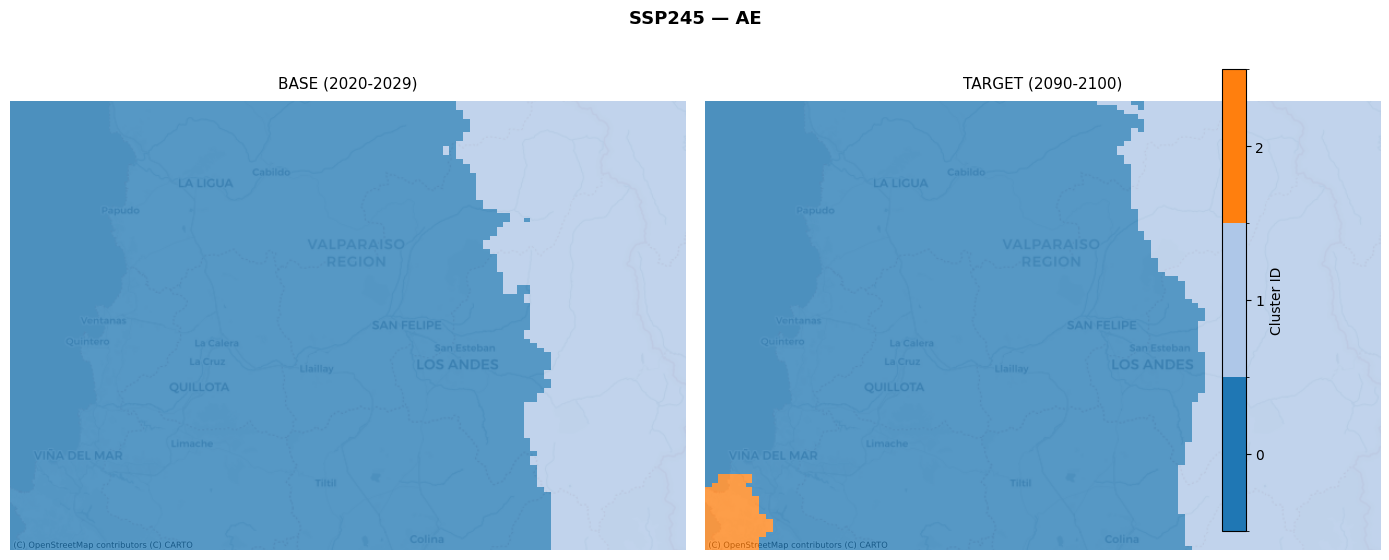

SSP370: 73/661 píxeles transicionan (11.0%)


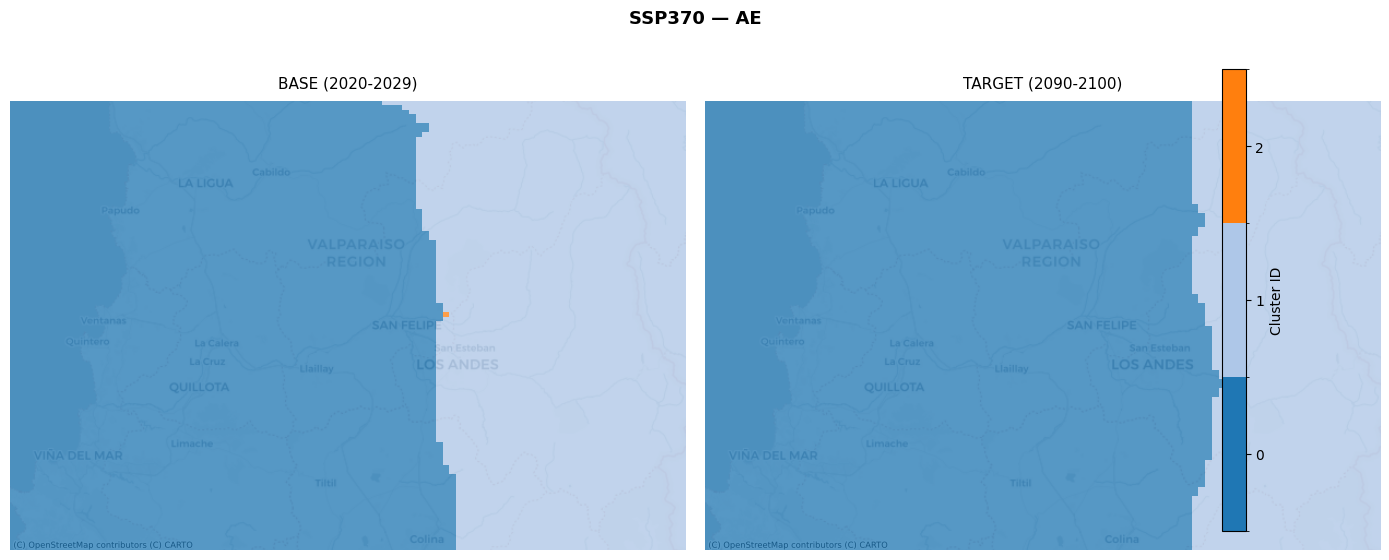

SSP585: 57/661 píxeles transicionan (8.6%)


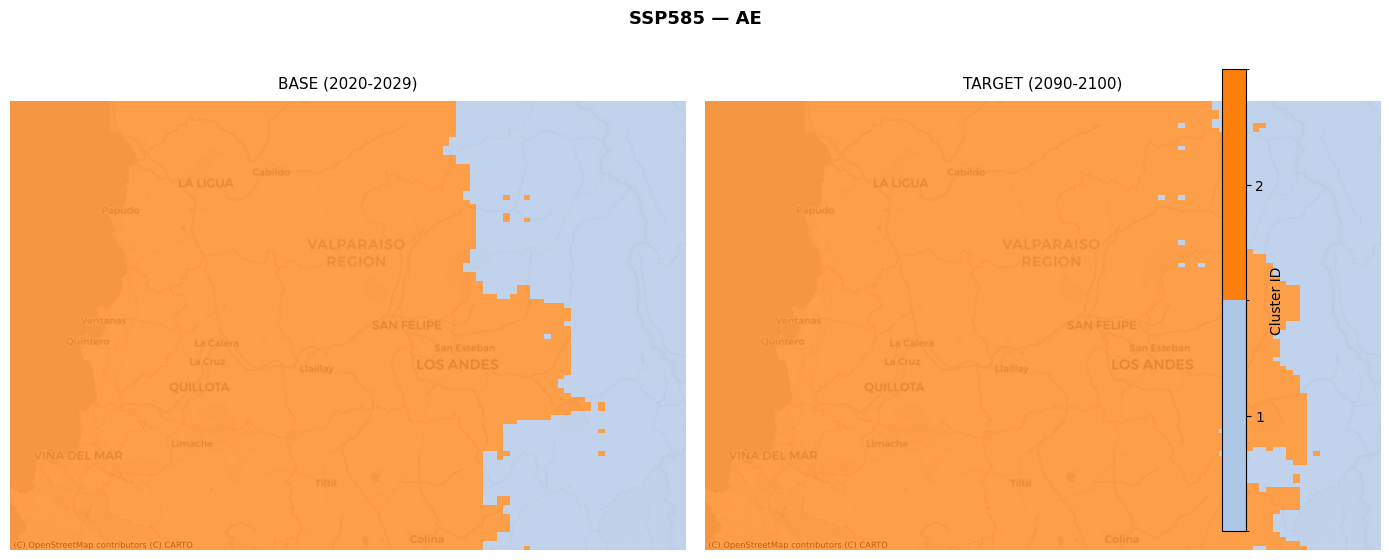


RESUMEN: Transiciones de cluster BASE → TARGET
  SSP245: 8.2% de píxeles cambian de cluster
  SSP370: 11.0% de píxeles cambian de cluster
  SSP585: 8.6% de píxeles cambian de cluster

  → Mayor % = mayor reordenamiento espacial del perfil climático
────────────────────────────────────────────────────────────


Comparación BASE → TARGET — VAE

Clusters únicos: [0 1 2]
Mostrando 3 comparaciones BASE → TARGET (una por trayectoria SSP)

SSP245: 28/661 píxeles transicionan (4.2%)


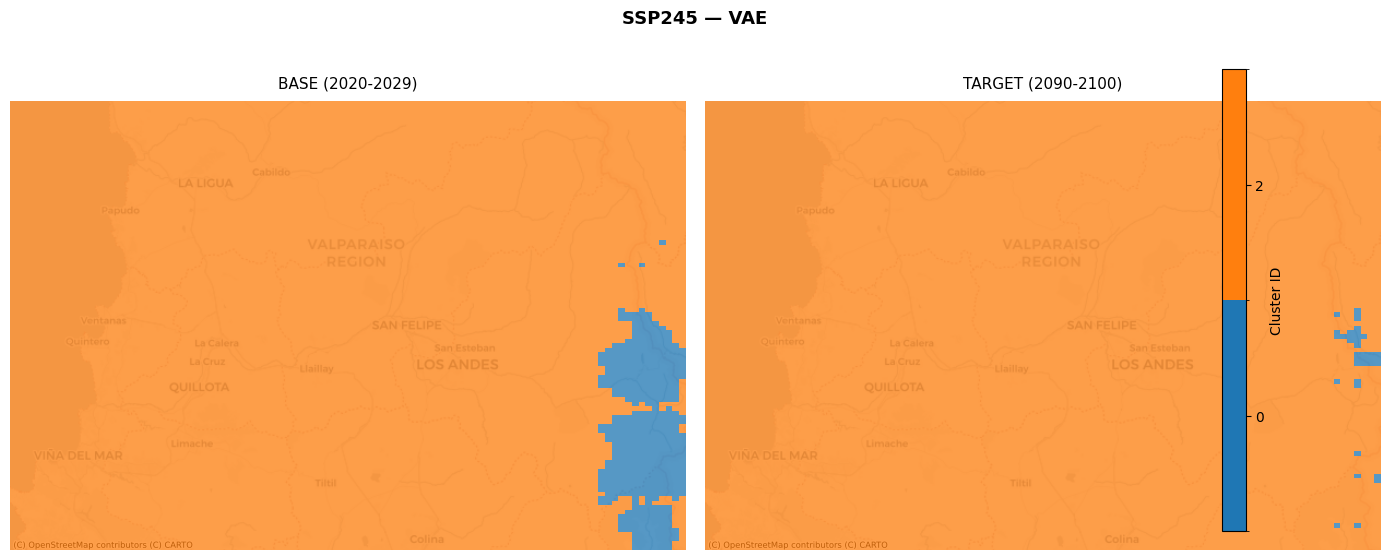

SSP370: 19/661 píxeles transicionan (2.9%)


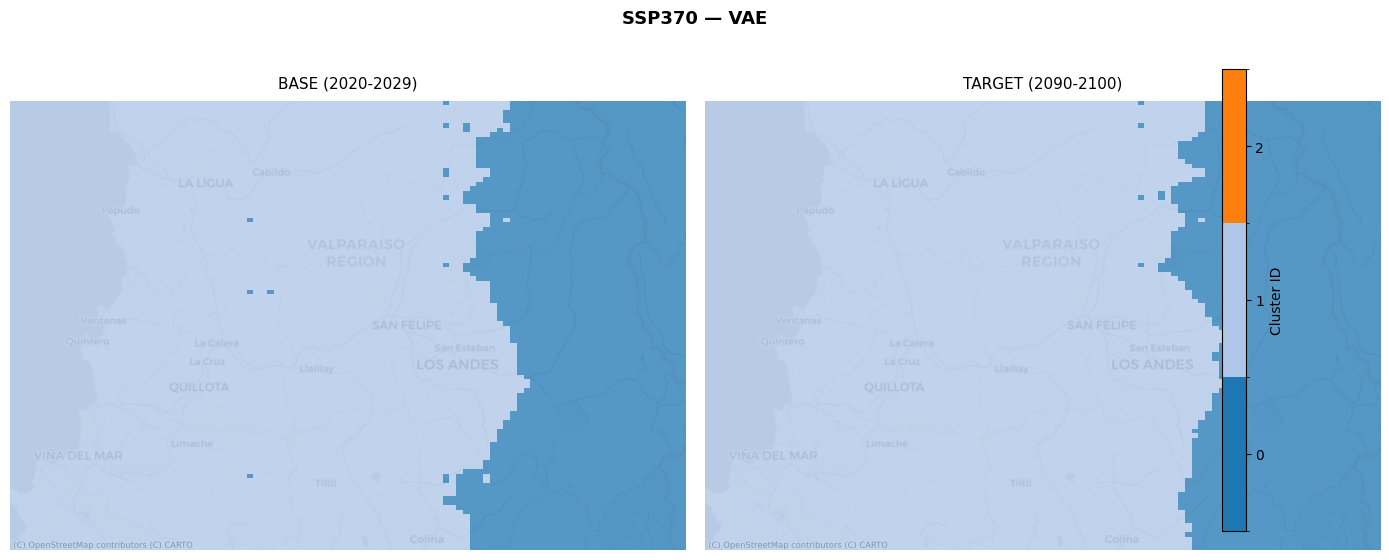

SSP585: 30/661 píxeles transicionan (4.5%)


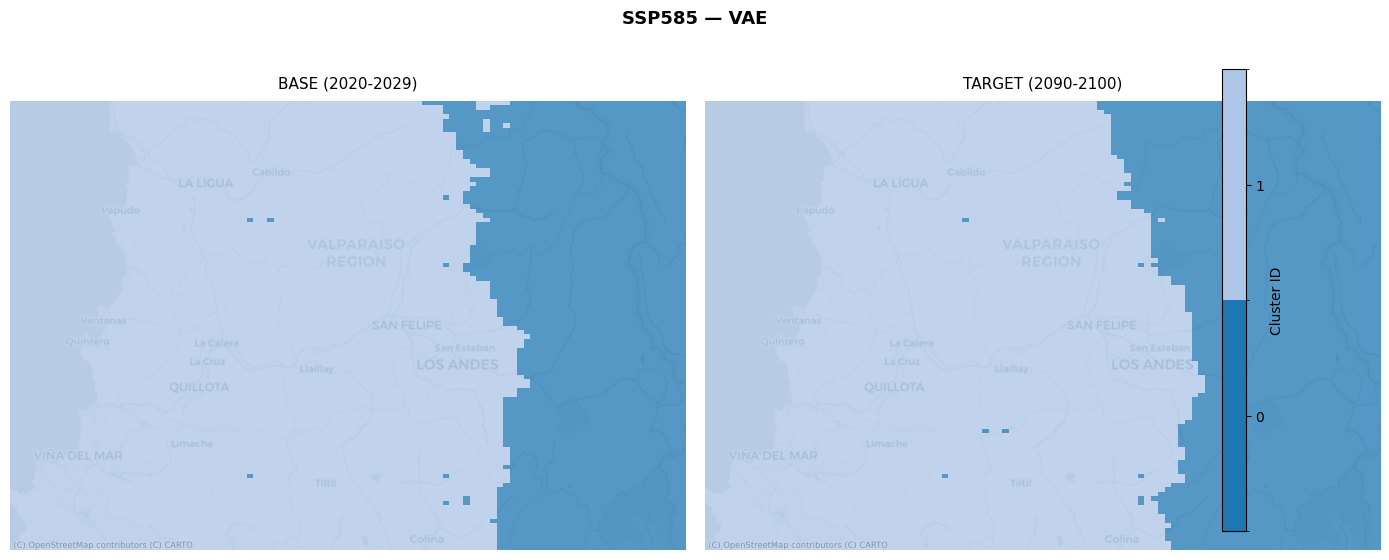


RESUMEN: Transiciones de cluster BASE → TARGET
  SSP245: 4.2% de píxeles cambian de cluster
  SSP370: 2.9% de píxeles cambian de cluster
  SSP585: 4.5% de píxeles cambian de cluster

  → Mayor % = mayor reordenamiento espacial del perfil climático
────────────────────────────────────────────────────────────


In [31]:
# Visualización espacial de los clusters BASE y futuros (TARGET)
# Formato: Comparación lado a lado (BASE | TARGET)

# Agregar directorio padre al path para importar módulo utils
import sys
import os
parent_dir = os.path.dirname(os.path.abspath(os.getcwd()))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Importar función desde módulo utils
from utils.plots import plot_spatial_comparisons_all_ssp

# Comparaciones BASE → TARGET para todos los modelos y escenarios
for model_key in MODEL_ORDER:
    print(f"\n{'='*60}")
    
    transition_stats = plot_spatial_comparisons_all_ssp(
        model_key=model_key,
        clustering_results=CLUSTERING_RESULTS[model_key],
        coords_df=coords_df,
        n_per_scenario=N_PER_SCENARIO,
        scenarios=["245", "370", "585"],
        alpha=0.75
    )
    
    print(f"{'─'*60}")

## 6. Cálculo automático del IRCT

Ahora calculamos el Índice de Resiliencia Climático-Territorial (IRCT) usando la librería modular.

**Componentes del IRCT:**
- **A**: Anomalía de reconstrucción (menor error = más resiliente)
- **S_D**: Estabilidad de desplazamiento latente (menor desplazamiento = más resiliente)
- **S_C**: Estabilidad de pertenencia a cluster (mayor probabilidad = más resiliente)
- **S_E**: Estabilidad de expansión (menor expansión = más resiliente)
- **S_H₂**: Estabilidad de producción H₂ (opcional)

**Fórmula:** IRCT = (A^w_a) × (S_D^w_d) × (S_C^w_c) × (S_E^w_e) × (S_H₂^w_h)

## 5.5 Preparación de datos para IRCT

Antes de calcular el IRCT, necesitamos preparar los datos correctamente:
- Verificar dimensionalidad de features
- Extraer el subset de features usado en el entrenamiento
- Preparar scaler si es necesario para desnormalización

In [32]:
# PREPARACIÓN DE DATOS PARA IRCT - CORRECCIÓN DE DIMENSIONALIDAD
print("PREPARANDO DATOS PARA CÁLCULO DE IRCT")
print("="*80)

# Dimensión esperada por los modelos
input_dim_expected = model_dims["AE"]["input_dim"]
print(f"\nDimensión esperada por modelos: {input_dim_expected}")
print(f"Dimensión actual de X_BASE: {X_BASE.shape[1]}")

# SOLUCIÓN: Usar las primeras input_dim features
# (El modelo fue entrenado con un subset de features)
print(f"\n→ Extrayendo las primeras {input_dim_expected} features...")

X_BASE_model = X_BASE[:, :input_dim_expected].copy()
X245_model = X245_orig[:, :input_dim_expected].copy()
X370_model = X370_orig[:, :input_dim_expected].copy()
X585_model = X585_orig[:, :input_dim_expected].copy()

print(f"\n✓ Dimensiones corregidas:")
print(f"  X_BASE_model: {X_BASE_model.shape}")
print(f"  X245_model: {X245_model.shape}")
print(f"  X370_model: {X370_model.shape}")
print(f"  X585_model: {X585_model.shape}")

# Verificación final
assert X_BASE_model.shape[1] == input_dim_expected, f"Error: {X_BASE_model.shape[1]} != {input_dim_expected}"
assert X245_model.shape[1] == input_dim_expected, f"Error: {X245_model.shape[1]} != {input_dim_expected}"
assert X_BASE_model.shape[0] == 3 * N_PER_SCENARIO, f"Error: {X_BASE_model.shape[0]} != {3 * N_PER_SCENARIO}"
assert X245_model.shape[0] == N_PER_SCENARIO, f"Error: {X245_model.shape[0]} != {N_PER_SCENARIO}"

print(f"\n{'='*80}")
print("✓ DATOS PREPARADOS CORRECTAMENTE")
print("="*80)

PREPARANDO DATOS PARA CÁLCULO DE IRCT

Dimensión esperada por modelos: 29
Dimensión actual de X_BASE: 29

→ Extrayendo las primeras 29 features...

✓ Dimensiones corregidas:
  X_BASE_model: (1983, 29)
  X245_model: (661, 29)
  X370_model: (661, 29)
  X585_model: (661, 29)

✓ DATOS PREPARADOS CORRECTAMENTE


In [33]:
# IMPORTANTE: REINICIAR EL KERNEL antes de ejecutar esta celda
# O ejecutar esta celda para forzar limpieza completa

import sys
import os

# Eliminar TODOS los módulos relacionados
modules_to_remove = [k for k in sys.modules.keys() if 'resilience' in k.lower()]
for mod in modules_to_remove:
    del sys.modules[mod]
    print(f"Módulo eliminado de memoria: {mod}")

# Agregar path
parent_dir = os.path.dirname(os.path.abspath(os.getcwd()))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Importar de nuevo
import resilience_lib
print(f"\nUsando resilience_lib desde: {resilience_lib.__file__}")

# Verificar que la función tiene la firma correcta
import inspect
sig = inspect.signature(resilience_lib.compute_reconstruction_anomaly)
print(f"Firma de compute_reconstruction_anomaly: {sig}")
print()

from resilience_lib import compute_IRCT_all_scenarios, aggregate_IRCT_by_cluster

# Configuración de pesos (puedes ajustarlos)
IRCT_WEIGHTS = {
    'w_a': 0.15,  # Reconstrucción
    'w_d': 0.30,  # Desplazamiento latente
    'w_c': 0.25,  # Estabilidad de cluster
    'w_e': 0.20,  # Expansión
    'w_h': 0.10   # H₂ (0.0 si no hay datos de H₂)
}

# Diccionario para almacenar resultados IRCT
IRCT_RESULTS = {}

print("CALCULANDO IRCT PARA TODOS LOS MODELOS Y ESCENARIOS")
print()

# Iterar sobre todos los modelos
for model_key in MODEL_ORDER:
    print(f"\nModelo: {model_key}")
    print(f"{'='*60}")
    
    # Calcular IRCT para los 3 escenarios (SSP245, SSP370, SSP585)
    # IMPORTANTE: usar X_*_model que tiene las features correctas
    irct_all = compute_IRCT_all_scenarios(
        model=MODELS[model_key],
        clustering_results=CLUSTERING_RESULTS[model_key],
        X_base_orig=X_BASE_model,
        X_base_norm=X_BASE_model,  # TODO: usar datos normalizados si están disponibles
        X245_orig=X245_model,
        X245_norm=X245_model,  # Sin normalización adicional por ahora
        X370_orig=X370_model,
        X370_norm=X370_model,
        X585_orig=X585_model,
        X585_norm=X585_model,
        n_per_scenario=N_PER_SCENARIO,
        h2_base=None,  # TODO: agregar datos de H₂ si están disponibles
        h2_245=None,
        h2_370=None,
        h2_585=None,
        weights=IRCT_WEIGHTS,
        device='cpu',
        verbose=True
    )
    
    IRCT_RESULTS[model_key] = irct_all
    
    print(f"\n{'─'*60}")

print(f"\n{'='*80}")
print(f"✓ IRCT calculado para {len(IRCT_RESULTS)} modelos × 3 escenarios")
print(f"  Variable IRCT_RESULTS lista para análisis")
print(f"{'='*80}")


Módulo eliminado de memoria: resilience_lib

Usando resilience_lib desde: /home/aninotna/magister/tesis/justh2_pipeline/scripts/idroverdi_autoencoder_3/resilience_lib.py
Firma de compute_reconstruction_anomaly: (model, X_orig, X_normalized, device='cpu', use_normalized=True, inverse_transform=None, reduce='mse', output='stability')

CALCULANDO IRCT PARA TODOS LOS MODELOS Y ESCENARIOS


Modelo: AE

Calculando IRCT para escenario T245...

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 29)
  X_normalized shape: (661, 29)
  device: cpu
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
  ✓ IRCT calculado para T245
    Media: 0.377
    Std: 0.056
    Min: 0.000
    Max: 0.512

Calculando IRCT para escenario T370...

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 29)
  X_normalized shape: (661, 29)
  device: cpu
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
  ✓ IRCT calculado para

## 7. Agregación del IRCT por cluster

Ahora agregamos las métricas del IRCT a nivel de cluster para facilitar la interpretación

In [34]:
# Agregar IRCT por cluster para todos los modelos y escenarios
IRCT_AGGREGATED = {}

print("AGREGANDO IRCT POR CLUSTER")
print()

for model_key in MODEL_ORDER:
    IRCT_AGGREGATED[model_key] = {}
    
    print(f"\nModelo: {model_key}")
    print(f"{'─'*60}")
    
    for scenario in ['T245', 'T370', 'T585']:
        # Obtener labels BASE correspondientes al escenario
        scenario_idx = ['T245', 'T370', 'T585'].index(scenario)
        label_key = ['labels_B245', 'labels_B370', 'labels_B585'][scenario_idx]
        labels_base = CLUSTERING_RESULTS[model_key][label_key]
        
        # Agregar por cluster
        agg_df = aggregate_IRCT_by_cluster(
            irct_results=IRCT_RESULTS[model_key][scenario],
            labels_base=labels_base,
            n_clusters=K_CLUSTERS,
            percentiles=[10, 50, 90]
        )
        
        IRCT_AGGREGATED[model_key][scenario] = agg_df
        
        # Mostrar resumen
        print(f"\n{scenario}:")
        display_cols = ['cluster_id', 'n_pixels', 'IRCT_mean', 'IRCT_std', 'IRCT_p10', 'IRCT_p90']
        if all(col in agg_df.columns for col in display_cols):
            print(agg_df[display_cols].sort_values('IRCT_mean', ascending=False).head(3).to_string(index=False))
        
        # Identificar cluster más y menos resiliente
        if len(agg_df) > 0:
            most_resilient_cluster = agg_df.loc[agg_df['IRCT_mean'].idxmax(), 'cluster_id']
            least_resilient_cluster = agg_df.loc[agg_df['IRCT_mean'].idxmin(), 'cluster_id']
            print(f"\n  → Cluster MÁS resiliente: {int(most_resilient_cluster)} "
                  f"(IRCT = {agg_df.loc[agg_df['IRCT_mean'].idxmax(), 'IRCT_mean']:.3f})")
            print(f"  → Cluster MENOS resiliente: {int(least_resilient_cluster)} "
                  f"(IRCT = {agg_df.loc[agg_df['IRCT_mean'].idxmin(), 'IRCT_mean']:.3f})")

print(f"\n{'='*80}")
print(f"✓ IRCT agregado por cluster para todos los modelos")
print(f"  Variable IRCT_AGGREGATED lista para análisis")
print(f"{'='*80}")

AGREGANDO IRCT POR CLUSTER


Modelo: AE
────────────────────────────────────────────────────────────

T245:
 cluster_id  n_pixels  IRCT_mean  IRCT_std  IRCT_p10  IRCT_p90
          0       481   0.393103  0.046268  0.338128  0.455784
          1       180   0.334861  0.057884  0.250788  0.396088

  → Cluster MÁS resiliente: 0 (IRCT = 0.393)
  → Cluster MENOS resiliente: 1 (IRCT = 0.335)

T370:
 cluster_id  n_pixels  IRCT_mean  IRCT_std  IRCT_p10  IRCT_p90
          0       398   0.430315  0.035532  0.385977  0.474037
          1       262   0.371945  0.056337  0.304043  0.429510
          2         1   0.289399  0.000000  0.289399  0.289399

  → Cluster MÁS resiliente: 0 (IRCT = 0.430)
  → Cluster MENOS resiliente: 2 (IRCT = 0.289)

T585:
 cluster_id  n_pixels  IRCT_mean  IRCT_std  IRCT_p10  IRCT_p90
          2       476   0.469699  0.047320  0.409303  0.525001
          1       185   0.351915  0.053051  0.296308  0.412796

  → Cluster MÁS resiliente: 2 (IRCT = 0.470)
  → Cluster MENO

## 8. Visualización de componentes del IRCT

Visualizamos los componentes individuales del IRCT para entender qué factores contribuyen más a la resiliencia

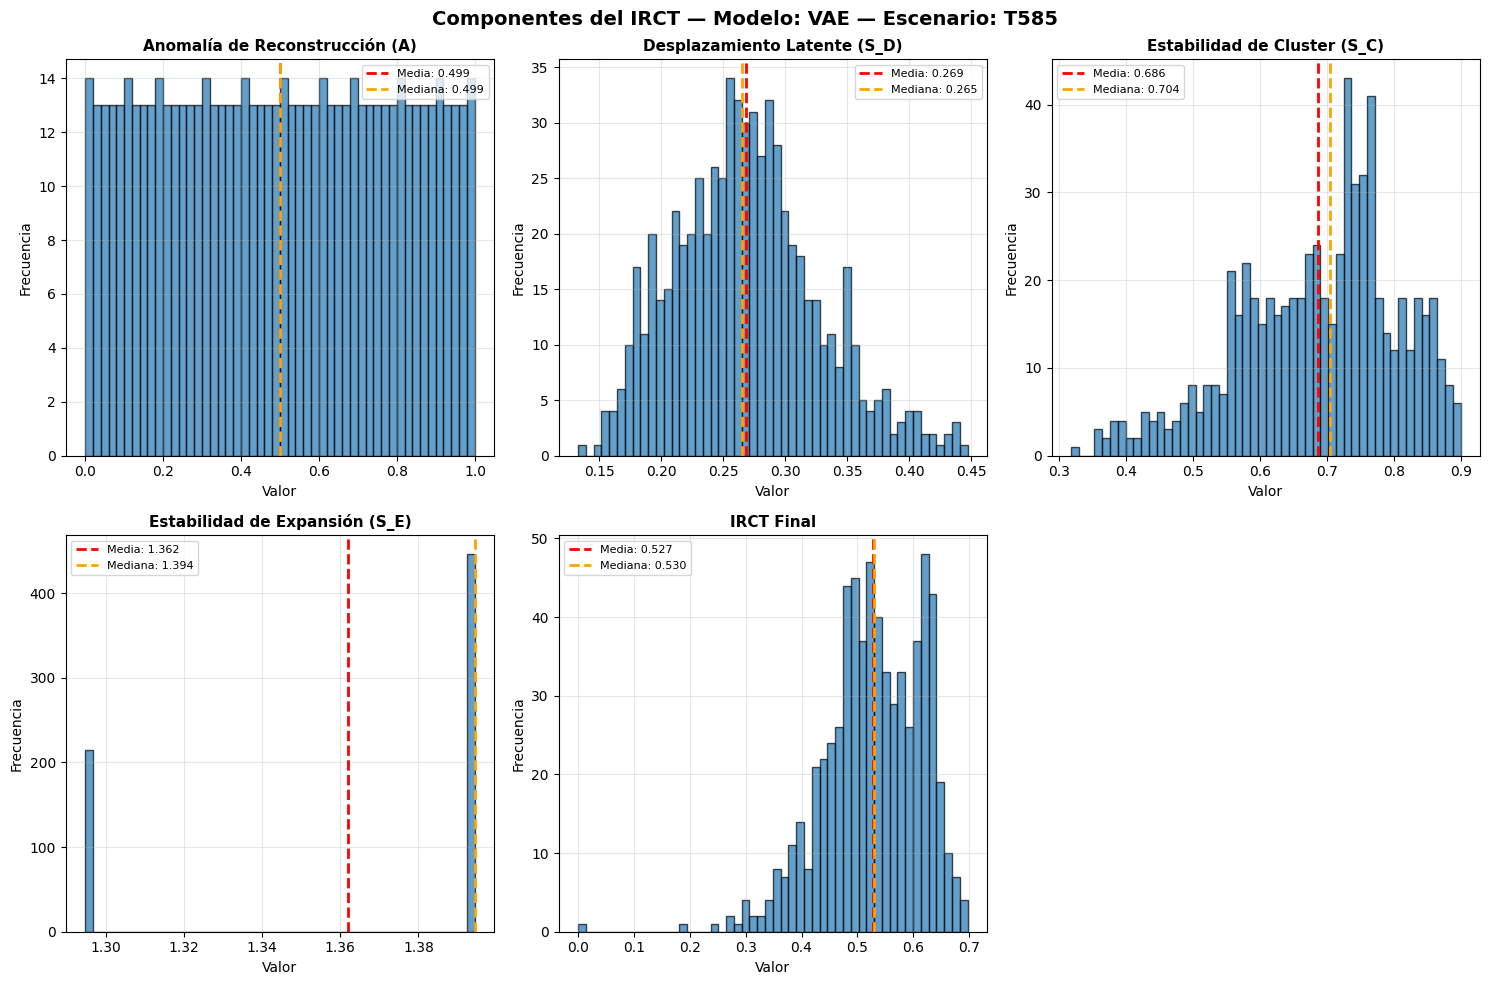


✓ Gráfico guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_components_VAE_T585.png


In [35]:
# Visualización de componentes del IRCT para SSP585
import matplotlib.pyplot as plt

# Configurar para SSP585 (el escenario más extremo)
scenario = 'T585'
model_key = 'VAE'  # Cambiar a 'AE' si prefieres

irct_data = IRCT_RESULTS[model_key][scenario]

# Crear figura con subplots para cada componente
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Componentes del IRCT — Modelo: {model_key} — Escenario: {scenario}', 
             fontsize=14, fontweight='bold')

components = [
    ('reconstruction_anomaly', 'Anomalía de Reconstrucción (A)'),
    ('latent_displacement', 'Desplazamiento Latente (S_D)'),
    ('cluster_stability', 'Estabilidad de Cluster (S_C)'),
    ('cluster_expansion', 'Estabilidad de Expansión (S_E)'),
    ('IRCT', 'IRCT Final')
]

for idx, (key, title) in enumerate(components):
    ax = axes.flatten()[idx]
    values = irct_data[key]
    
    if values is not None:
        ax.hist(values, bins=50, alpha=0.7, edgecolor='black')
        ax.axvline(values.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {values.mean():.3f}')
        ax.axvline(np.median(values), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(values):.3f}')
        ax.set_xlabel('Valor', fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

# Ocultar subplot vacío
axes.flatten()[5].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'irct_components_{model_key}_{scenario}.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfico guardado en: {os.path.join(PLOTS_DIR, f'irct_components_{model_key}_{scenario}.png')}")

## 9. Visualización espacial del IRCT

Visualizamos la distribución espacial del IRCT y sus componentes en el Valle de Aconcagua

Visualizando IRCT espacial para VAE — T585
Número de píxeles: 661

1. IRCT completo (con interpolación y basemap):
  → Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_spatial_interpolated_VAE_T585.png


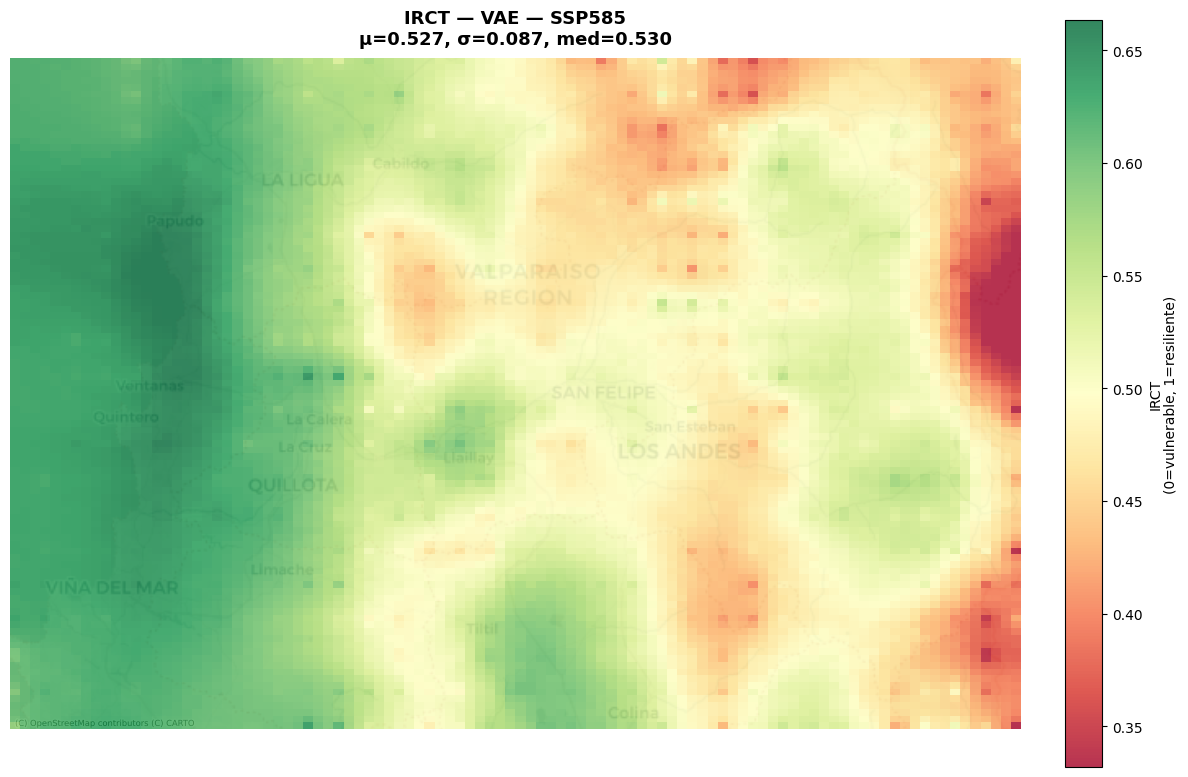

In [36]:
# Importar funciones de visualización espacial con interpolación KNN y basemap
from resilience_lib import plot_IRCT_spatial, plot_IRCT_components_spatial, plot_IRCT_vs_clusters_comparison

# Configuración
scenario = 'T585'  # Cambiar a 'T245' o 'T370' si prefieres
model_key = 'VAE'  # Cambiar a 'AE' si prefieres

print(f"Visualizando IRCT espacial para {model_key} — {scenario}")
print(f"Número de píxeles: {len(coords_df)}")
print()

# 1. Visualización del IRCT completo con interpolación KNN y basemap
print("1. IRCT completo (con interpolación y basemap):")
fig, ax = plot_IRCT_spatial(
    irct_results=IRCT_RESULTS[model_key][scenario],
    coords_df=coords_df,
    metric='IRCT',
    scenario=f'SSP{scenario[1:]}',
    model_key=model_key,
    n_neighbors=15,  # Vecinos para interpolación KNN
    grid_res=100,    # Resolución de la grilla
    figsize=(12, 8),
    cmap='RdYlGn',  # Verde = más resiliente, Rojo = menos resiliente
    alpha=0.8,
    use_basemap=True,  # Agregar mapa base geográfico
    save_path=os.path.join(PLOTS_DIR, f'irct_spatial_interpolated_{model_key}_{scenario}.png'),
    dpi=300
)

print()

2. Panel de descomposición del IRCT con interpolación KNN:
  → Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_components_interpolated_VAE_T585.png


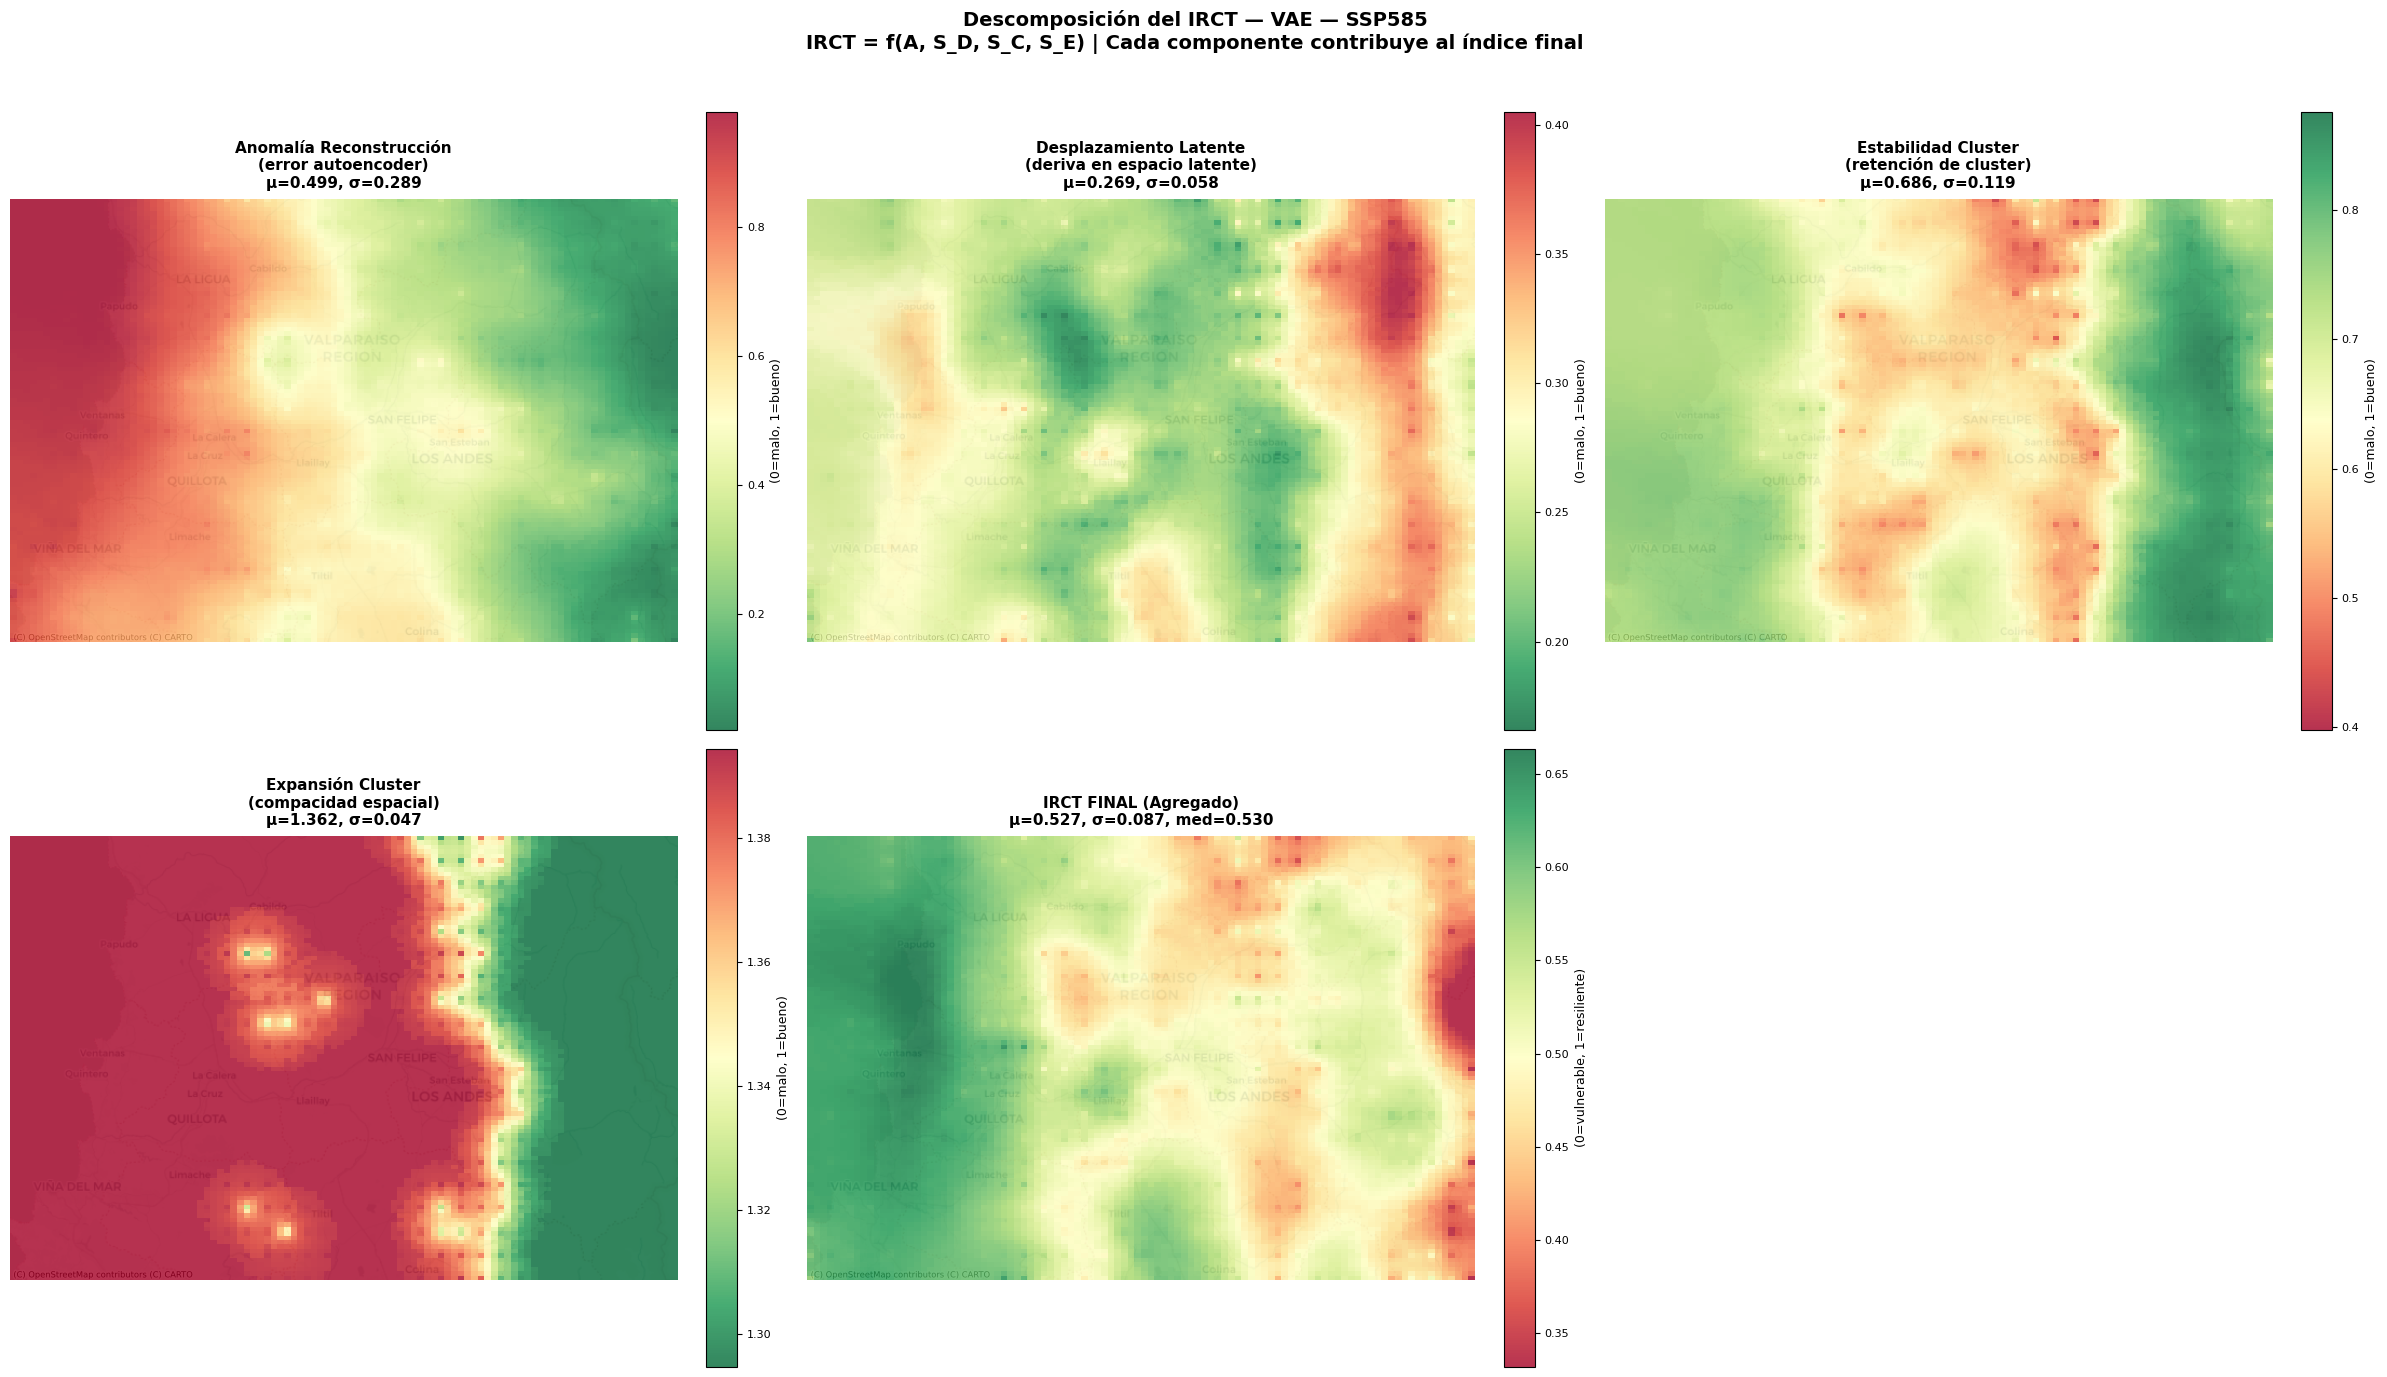


✓ Panel de componentes guardado


In [37]:
# 2. Panel completo con TODOS los componentes del IRCT (con interpolación)
print("2. Panel de descomposición del IRCT con interpolación KNN:")
fig, axes = plot_IRCT_components_spatial(
    irct_results=IRCT_RESULTS[model_key][scenario],
    coords_df=coords_df,
    scenario=f'SSP{scenario[1:]}',
    model_key=model_key,
    n_neighbors=15,
    grid_res=100,
    figsize=(24, 14),
    alpha=0.8,
    use_basemap=True,
    save_path=os.path.join(PLOTS_DIR, f'irct_components_interpolated_{model_key}_{scenario}.png'),
    dpi=300
)

print(f"\n✓ Panel de componentes guardado")

3. Comparación IRCT vs estructura de clusters:
  → Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_vs_clusters_VAE_T585.png


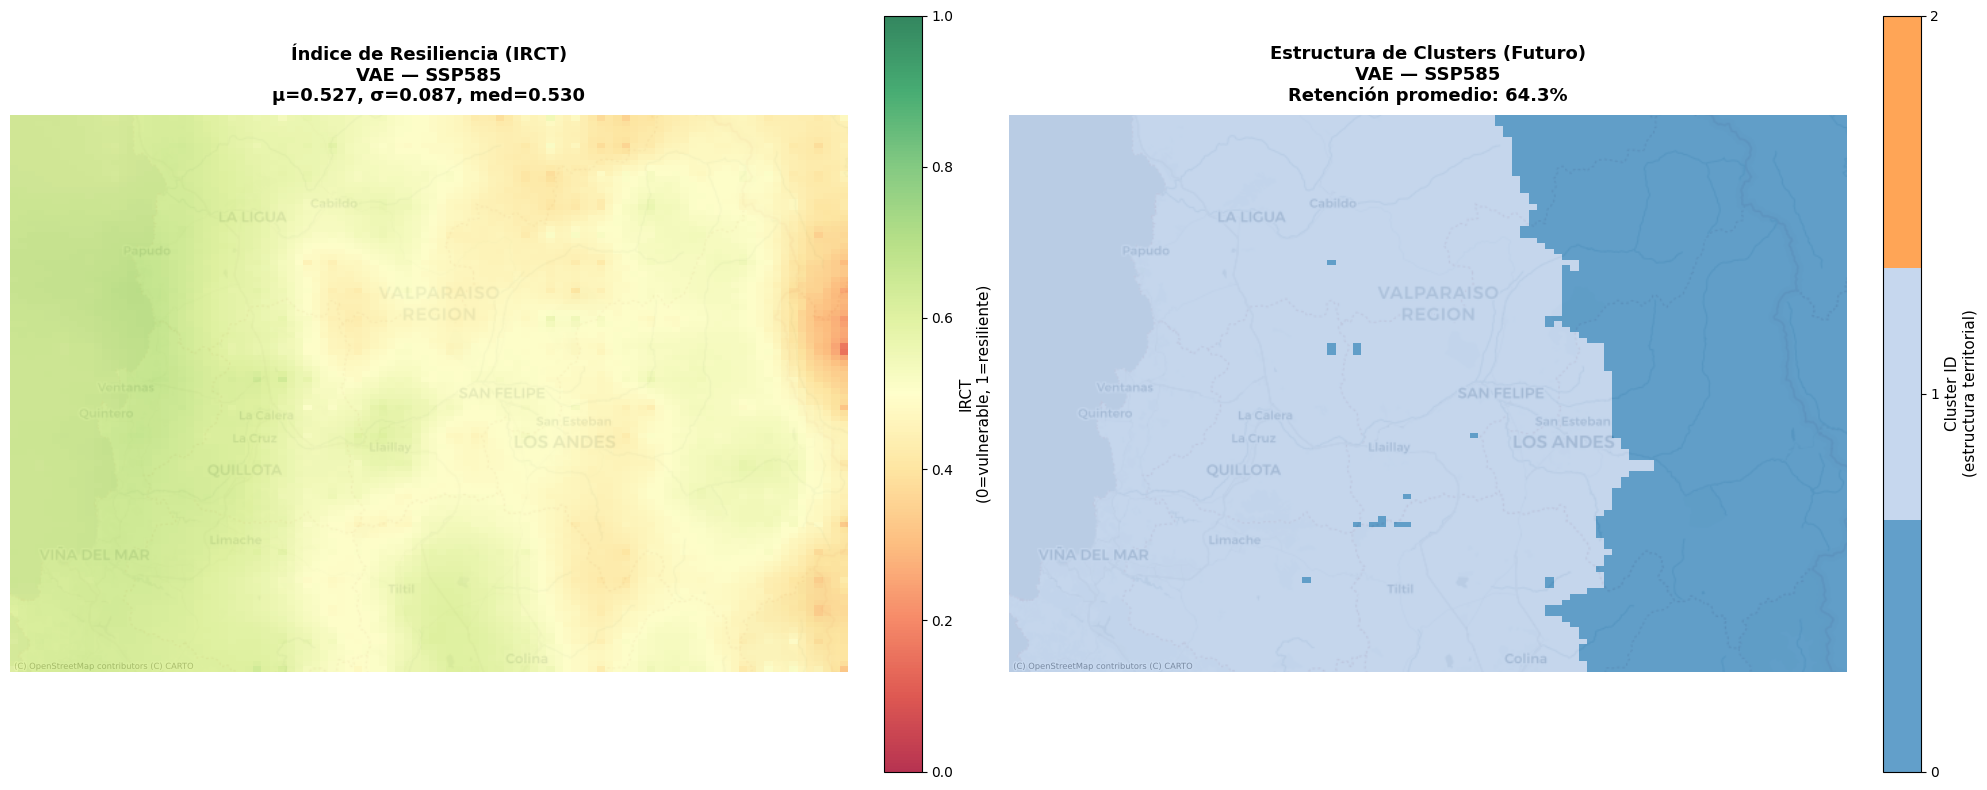


✓ Comparación IRCT vs clusters guardada


In [38]:
# 3. Comparación lado a lado: IRCT vs Clusters
print("3. Comparación IRCT vs estructura de clusters:")
fig, (ax1, ax2) = plot_IRCT_vs_clusters_comparison(
    irct_results=IRCT_RESULTS[model_key][scenario],
    clustering_results=CLUSTERING_RESULTS[model_key],
    coords_df=coords_df,
    scenario=scenario,
    model_key=model_key,
    n_clusters=K_CLUSTERS,
    n_neighbors=15,
    grid_res=100,
    figsize=(20, 8),
    alpha=0.8,
    use_basemap=True,
    save_path=os.path.join(PLOTS_DIR, f'irct_vs_clusters_{model_key}_{scenario}.png'),
    dpi=300
)

print(f"\n✓ Comparación IRCT vs clusters guardada")

## 10. Comparación espacial entre modelos AE vs VAE

Comparamos cómo cada modelo (AE vs VAE) percibe la resiliencia climática en el territorio

4. Componentes individuales con interpolación (ejemplos):

a) Desplazamiento Latente (S_D):
  → Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_displacement_VAE_T585.png


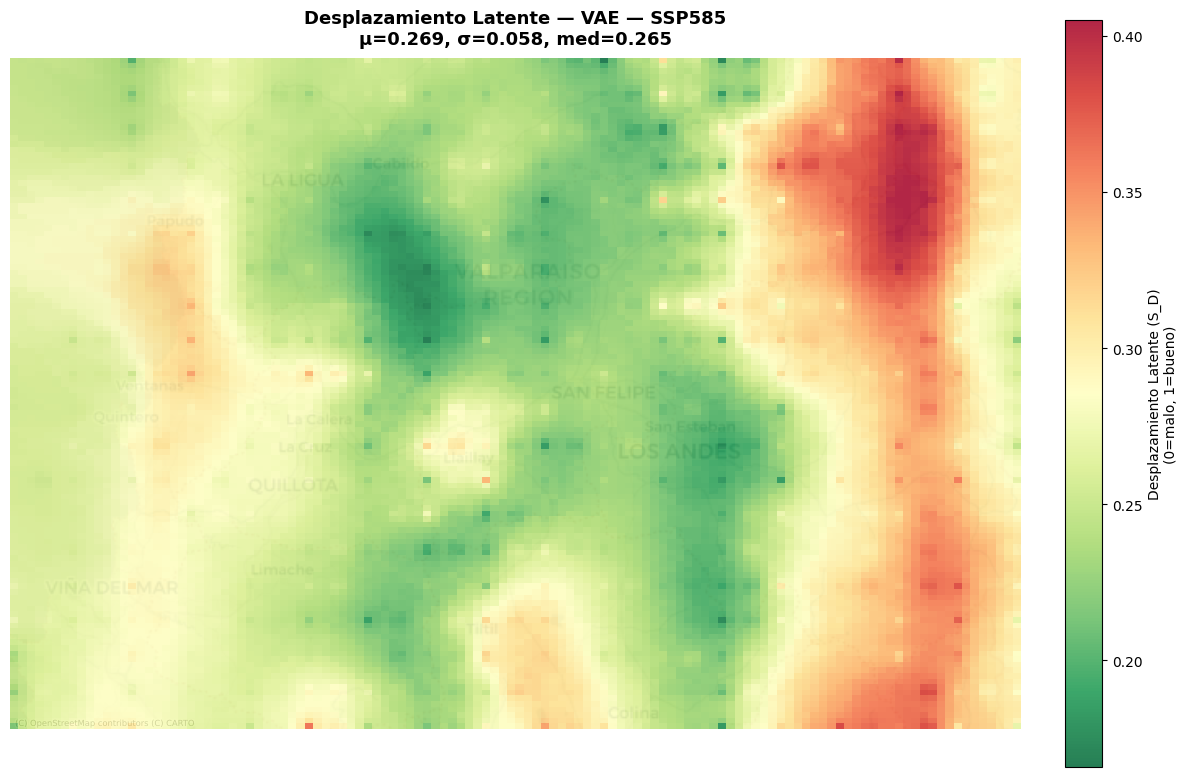


b) Estabilidad de Cluster (S_C):
  → Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_cluster_stability_VAE_T585.png


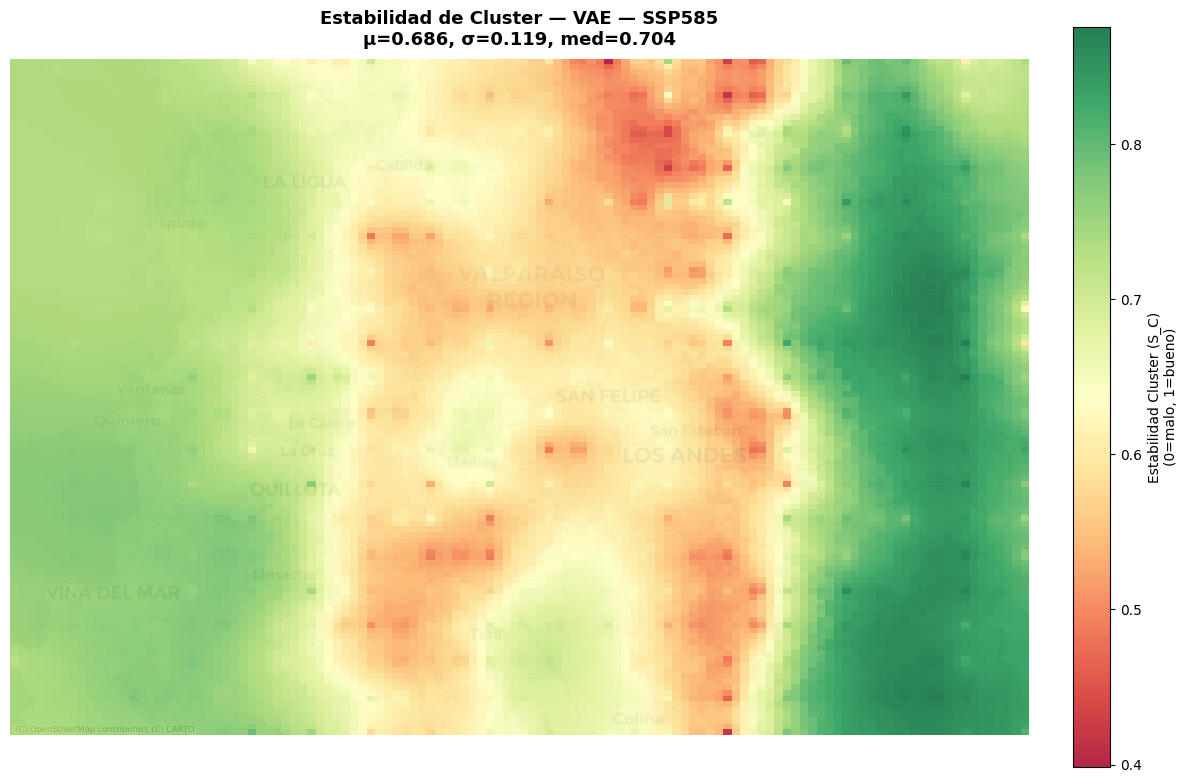


✓ Componentes individuales guardados


In [39]:
# 4. Visualizaciones individuales de componentes específicos (opcional)
# Si necesitas explorar componentes específicos con más detalle

print("4. Componentes individuales con interpolación (ejemplos):")
print()

# Ejemplo: Solo el componente de Desplazamiento Latente
print("a) Desplazamiento Latente (S_D):")
fig, ax = plot_IRCT_spatial(
    irct_results=IRCT_RESULTS[model_key][scenario],
    coords_df=coords_df,
    metric='latent_displacement',
    scenario=f'SSP{scenario[1:]}',
    model_key=model_key,
    n_neighbors=15,
    grid_res=120,
    figsize=(12, 8),
    cmap='RdYlGn_r',  # Invertido para que rojo = mayor desplazamiento
    alpha=0.85,
    use_basemap=True,
    save_path=os.path.join(PLOTS_DIR, f'irct_displacement_{model_key}_{scenario}.png'),
    dpi=300
)
print()

# Ejemplo: Estabilidad de cluster
print("b) Estabilidad de Cluster (S_C):")
fig, ax = plot_IRCT_spatial(
    irct_results=IRCT_RESULTS[model_key][scenario],
    coords_df=coords_df,
    metric='cluster_stability',
    scenario=f'SSP{scenario[1:]}',
    model_key=model_key,
    n_neighbors=15,
    grid_res=120,
    figsize=(12, 8),
    cmap='RdYlGn',
    alpha=0.85,
    use_basemap=True,
    save_path=os.path.join(PLOTS_DIR, f'irct_cluster_stability_{model_key}_{scenario}.png'),
    dpi=300
)

print(f"\n✓ Componentes individuales guardados")

5. Comparación AE vs VAE (con interpolación):



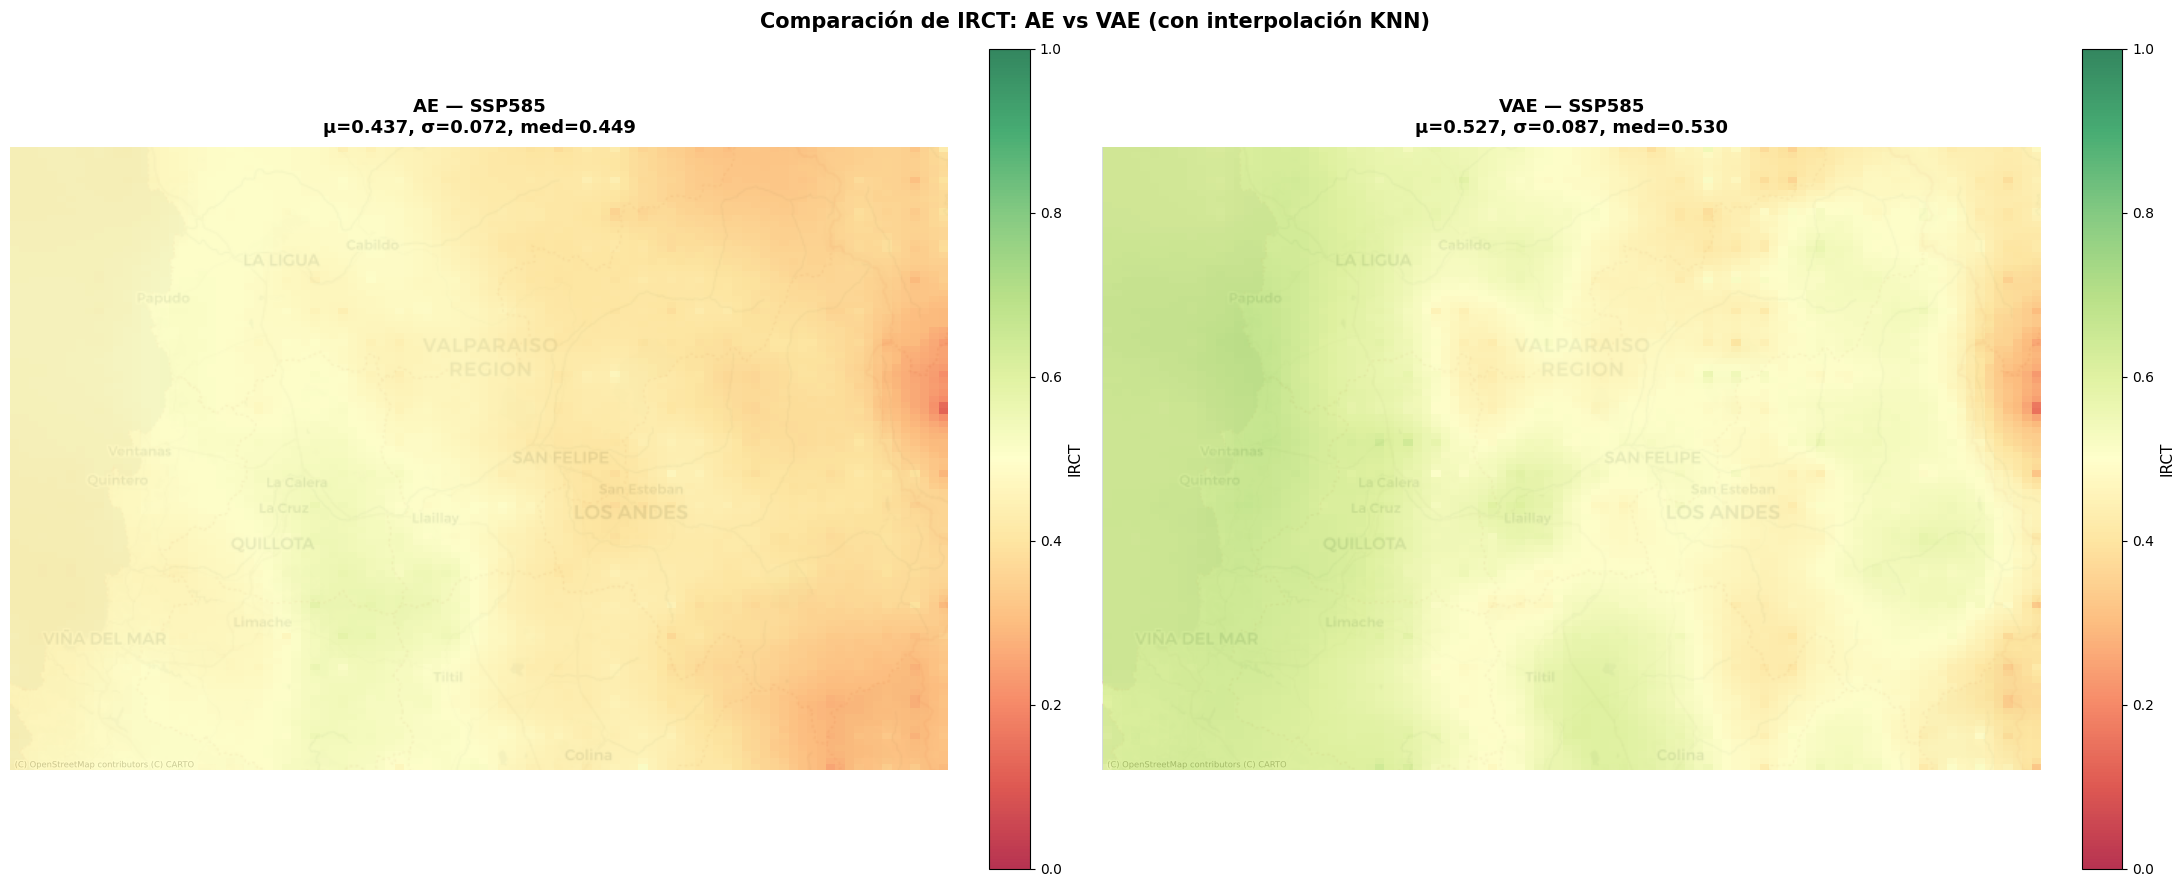


✓ Comparación AE vs VAE guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/irct_comparison_AE_vs_VAE_T585_interpolated.png


In [40]:
# 5. Comparación AE vs VAE para el mismo escenario (usando las funciones mejoradas)
print("5. Comparación AE vs VAE (con interpolación):")
print()

scenario = 'T585'
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for idx, model_key in enumerate(MODEL_ORDER):
    ax = axes[idx]
    
    # Obtener datos
    irct_vals = IRCT_RESULTS[model_key][scenario]['IRCT']
    lats = coords_df['lat'].values
    lons = coords_df['lon'].values
    
    # Transformar a Web Mercator
    try:
        from pyproj import Transformer
        from sklearn.neighbors import KNeighborsRegressor
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
        xs, ys = transformer.transform(lons, lats)
        
        # Crear grid
        grid_x = np.linspace(xs.min(), xs.max(), 100)
        grid_y = np.linspace(ys.min(), ys.max(), 100)
        GX, GY = np.meshgrid(grid_x, grid_y)
        extent = (grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max())
        
        # Interpolación
        valid_mask = ~(np.isnan(irct_vals) | np.isinf(irct_vals))
        coords = np.column_stack([xs[valid_mask], ys[valid_mask]])
        vals = irct_vals[valid_mask]
        
        knn = KNeighborsRegressor(n_neighbors=15, weights="distance")
        knn.fit(coords, vals)
        grid_points = np.column_stack([GX.ravel(), GY.ravel()])
        pred_irct = knn.predict(grid_points).reshape(GX.shape)
        
        # Configurar axes
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        
        # Basemap
        try:
            import contextily as ctx
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                          crs="EPSG:3857", alpha=1.0, attribution_size=6, zoom='auto')
        except:
            pass
        
        # Overlay
        im = ax.imshow(pred_irct, extent=extent, origin="lower",
                      cmap='RdYlGn', alpha=0.8, vmin=0, vmax=1, zorder=3)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('IRCT', fontsize=11)
        
        # Estadísticos
        mean_val = vals.mean()
        std_val = vals.std()
        median_val = np.median(vals)
        
        ax.set_title(
            f'{model_key} — SSP{scenario[1:]}\nμ={mean_val:.3f}, σ={std_val:.3f}, med={median_val:.3f}',
            fontsize=13,
            fontweight='bold',
            pad=10
        )
        ax.set_axis_off()
        
    except Exception as e:
        print(f"Error en {model_key}: {e}")
        # Fallback a scatter simple
        scatter = ax.scatter(lons, lats, c=irct_vals, cmap='RdYlGn',
                           vmin=0, vmax=1, s=20, alpha=0.8, edgecolors='none')
        plt.colorbar(scatter, ax=ax)
        ax.set_title(f'{model_key} — SSP{scenario[1:]}', fontsize=13, fontweight='bold')
        ax.grid(alpha=0.3)

plt.suptitle('Comparación de IRCT: AE vs VAE (con interpolación KNN)', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, f'irct_comparison_AE_vs_VAE_{scenario}_interpolated.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparación AE vs VAE guardada: {save_path}")